In [46]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.configure_scienceplots import configure_scienceplots  # noqa: E402
from utils.constants import FIGURES_DIR  # noqa: E402
from utils.load_data import (  # noqa: E402
    load_processed_original_data,
    resample_data,
)

FIGSIZE = (10, 6)

BOXPLOT_FIGURES_DIR = FIGURES_DIR / "boxplots"
BOXPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VIOLINPLOT_FIGURES_DIR = FIGURES_DIR / "violinplots"
VIOLINPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [47]:
configure_scienceplots()

In [66]:
df = load_processed_original_data(parse_dates=True)
df.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


## Related to hours

### Boxplots

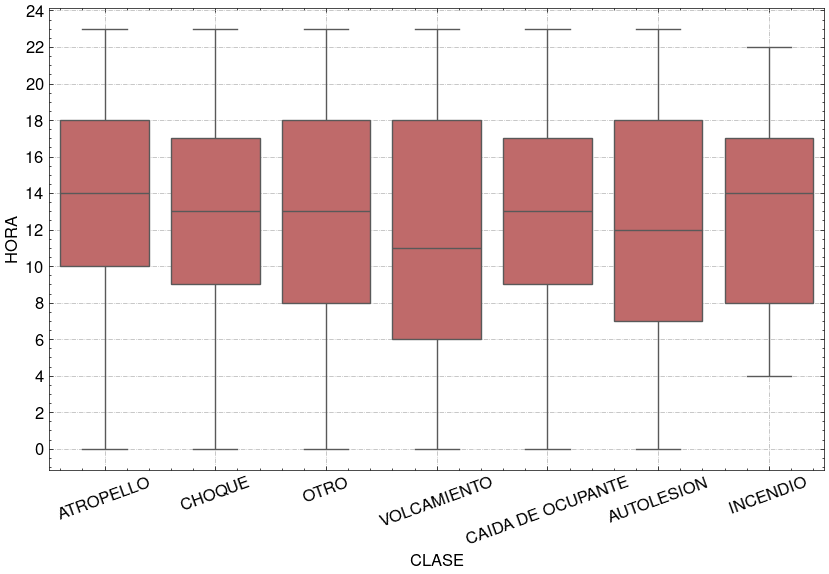

In [82]:
df["HORA"] = df["FECHA_OCURRENCIA"].dt.hour

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(x="CLASE", y="HORA", color="indianred", data=df, ax=ax)
plt.xticks(rotation=20, ha="center")
plt.yticks(ticks=range(0, 24 + 1, 2))

ax.grid(linestyle="-.")

fig.savefig(BOXPLOT_FIGURES_DIR / "clase_hour.pdf")
plt.show()

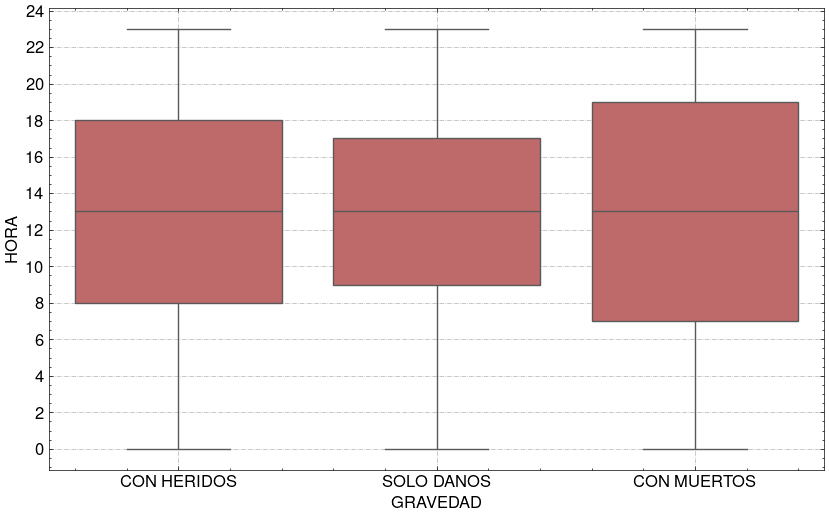

In [83]:
df["HORA"] = df["FECHA_OCURRENCIA"].dt.hour

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(x="GRAVEDAD", y="HORA", color="indianred", data=df, ax=ax)
plt.xticks(rotation=0, ha="center")
plt.yticks(ticks=range(0, 24 + 1, 2))

ax.grid(linestyle="-.")
fig.savefig(BOXPLOT_FIGURES_DIR / "gravedad_hour.pdf")
plt.show()

/tmp/ipykernel_206888/2044672547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


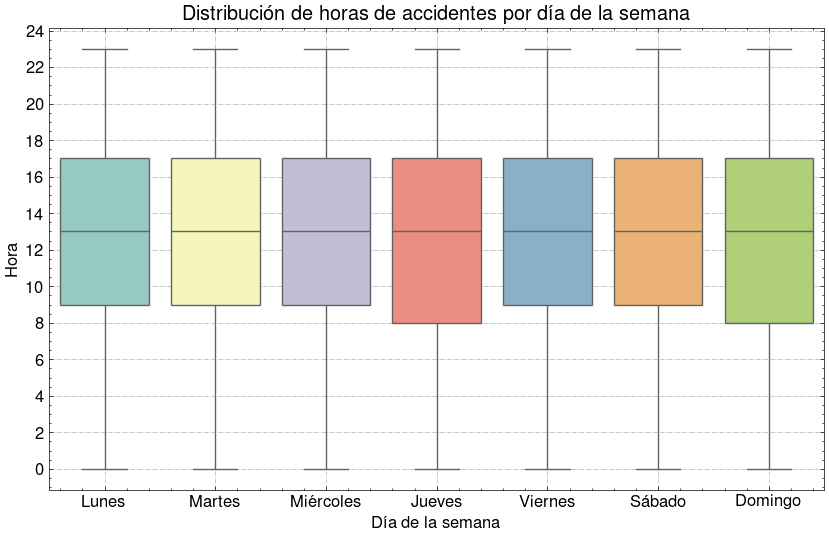

In [84]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(
    x="DIA_SEMANA_OCURRENCIA",
    y="HORA",
    palette="Set3",
    data=df,
    ax=ax,
    zorder=10,
)

ax.set(
    title="Distribución de horas de accidentes por día de la semana",
    xlabel="Día de la semana",
    ylabel="Hora",
)

plt.xticks(
    ticks=range(7),
    rotation=0,
    ha="center",
    labels=[
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo",
    ],
)

plt.yticks(ticks=range(0, 24 + 1, 2))

ax.grid(linestyle="-.")
fig.savefig(BOXPLOT_FIGURES_DIR / "dayofweek_hour.pdf")
plt.show()

### Violinplots

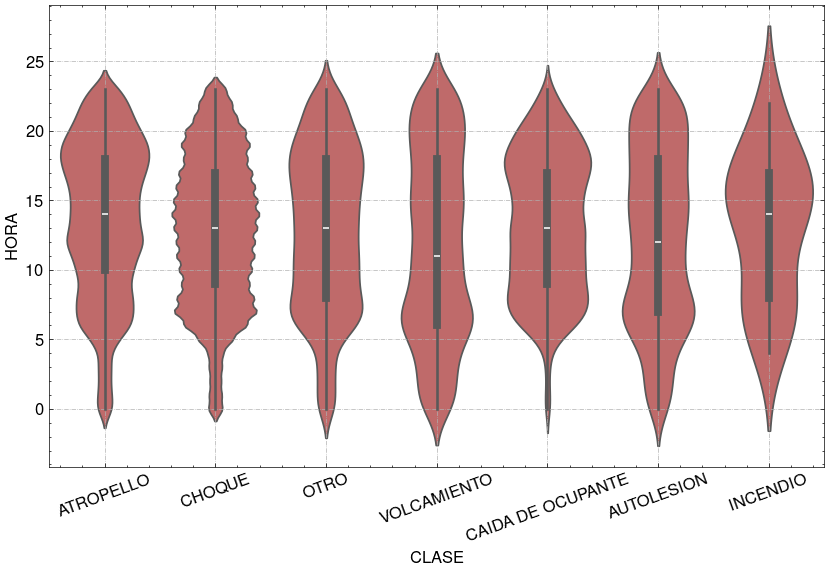

In [85]:
df["HORA"] = df["FECHA_OCURRENCIA"].dt.hour

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.violinplot(x="CLASE", y="HORA", color="indianred", data=df, ax=ax)
plt.xticks(rotation=20, ha="center")
# plt.yticks(ticks=range(0, 24, 2))

ax.grid(linestyle="-.")

fig.savefig(VIOLINPLOT_FIGURES_DIR / "clase_hour.pdf")
plt.show()

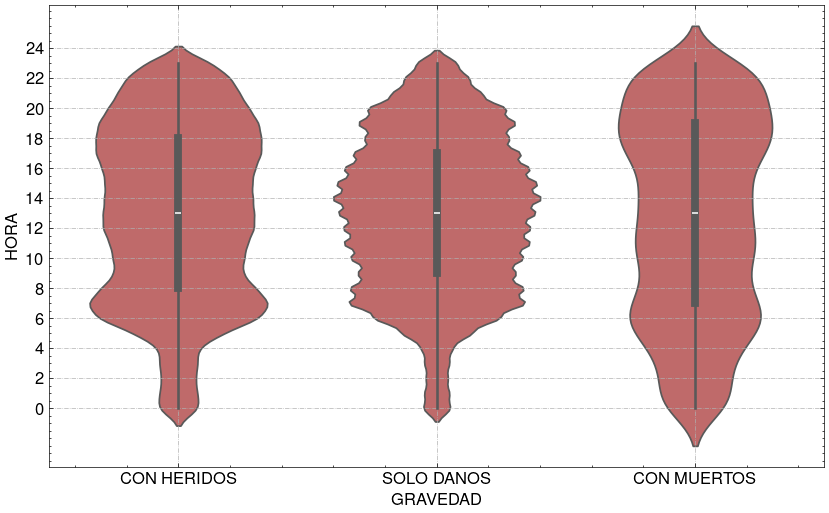

In [86]:
df["HORA"] = df["FECHA_OCURRENCIA"].dt.hour

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.violinplot(x="GRAVEDAD", y="HORA", color="indianred", data=df, ax=ax)
plt.xticks(rotation=0, ha="center")
plt.yticks(ticks=range(0, 24 + 1, 2))

ax.grid(linestyle="-.")
fig.savefig(VIOLINPLOT_FIGURES_DIR / "gravedad_hour.pdf")
plt.show()

/tmp/ipykernel_206888/1711550100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


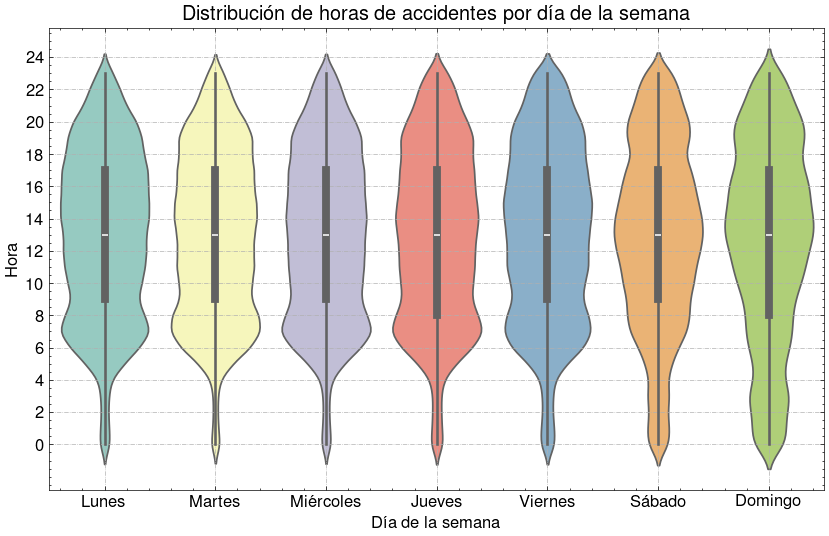

In [87]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.violinplot(
    x="DIA_SEMANA_OCURRENCIA",
    y="HORA",
    palette="Set3",
    data=df,
    ax=ax,
)

ax.set(
    title="Distribución de horas de accidentes por día de la semana",
    xlabel="Día de la semana",
    ylabel="Hora",
)

plt.xticks(
    ticks=range(7),
    rotation=0,
    ha="center",
    labels=[
        "Lunes",
        "Martes",
        "Miércoles",
        "Jueves",
        "Viernes",
        "Sábado",
        "Domingo",
    ],
)

plt.yticks(ticks=range(0, 24 + 1, 2))

ax.grid(linestyle="-.")
fig.savefig(VIOLINPLOT_FIGURES_DIR / "dayofweek_hour.pdf")
plt.show()

## GRAVEDAD and CLASE using resample data

In [88]:
resample_df = resample_data(freq="1W", multi_index=True)
resample_df.head()

TOTAL_ACCIDENTES   GRAVEDAD                          CLASE  \
                                  SOLO DANOS CON HERIDOS CON MUERTOS CHOQUE   
FECHA_OCURRENCIA                                                              
2007-01-07                    473        250         216           7    350   
2007-01-14                    496        299         191           6    383   
2007-01-21                    675        372         292          11    499   
2007-01-28                    685        398         280           7    499   
2007-02-04                    702        389         301          12    514   

                                                                        ...  \
                 ATROPELLO VOLCAMIENTO OTRO CAIDA DE OCUPANTE INCENDIO  ...   
FECHA_OCURRENCIA                                                        ...   
2007-01-07              61          33   20                 9        0  ...   
2007-01-14              64          23   15                11        0  ...   
2007-01-21              83          39   37                17        0  ...   
2007-01-28              95          28   46                17        0  ...   
2007-02-04              96          25   45                22        0  ...   

                      LOCALIDAD                 DIA_SEMANA_OCURRENCIA  \
                 ANTONIO NARIÑO USME CANDELARIA                Jueves   
FECHA_OCURRENCIA                                                        
2007-01-07                   12   10          3                    81   
2007-01-14                    6   10          4                    77   
2007-01-21                   11   10          4                    95   
2007-01-28                   15    7          3                   112   
2007-02-04                   16    8          3                    69   

                                                                
                 Miercoles Martes Viernes Domingo Sábado Lunes  
FECHA_OCURRENCIA                                                
2007-01-07              76     71      70      64     61    50  
2007-01-14              73     59      95      56     90    46  
2007-01-21             101    100      91      73    114   101  
2007-01-28             118    108      98      70     94    85  
2007-02-04             103    104     135      77    117    97  

[5 rows x 37 columns]

In [89]:
def transform_resample_data_for_boxplot(
    df: pd.DataFrame,
    col: str,
    multi_index: bool = False,
) -> pd.DataFrame:
    filtered_df: pd.DataFrame

    if multi_index:
        filtered_df = df[col]
    else:
        interest_columns = list(
            filter(lambda df_col: df_col.startswith(col), df.columns)
        )
        columns = list(
            map(
                lambda df_col: df_col.split("-")[1].replace("_", " ").strip(),
                interest_columns,
            )
        )
        filtered_df = pd.DataFrame()
        for i in range(len(interest_columns)):
            filtered_df[columns[i]] = df[interest_columns[i]]

    col_type = []
    values = []
    indexes = []
    for index, row in filtered_df.iterrows():
        for c in filtered_df.columns:
            col_type.append(c)
            values.append(row[c])
            indexes.append(index)

    new_df = pd.DataFrame(
        {
            col: col_type,
            "value": values,
        },
        index=indexes,
    )

    return new_df

### GRAVEDAD

In [90]:
gravity_df = transform_resample_data_for_boxplot(
    resample_df, "GRAVEDAD", multi_index=True
)

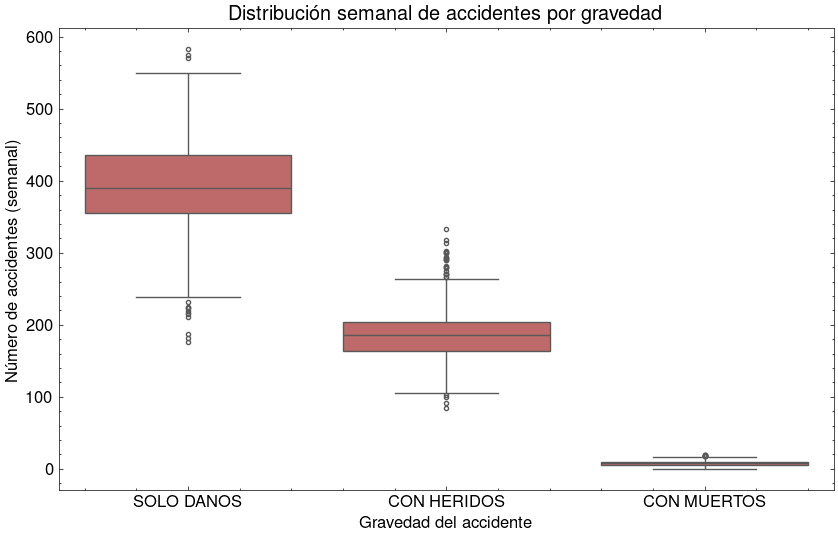

In [91]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(
    x="GRAVEDAD",
    y="value",
    color="indianred",
    data=gravity_df,
    ax=ax,
)

ax.set(
    title="Distribución semanal de accidentes por gravedad",
    xlabel="Gravedad del accidente",
    ylabel="Número de accidentes (semanal)",
)

plt.xticks(rotation=0, ha="center")
fig.savefig(BOXPLOT_FIGURES_DIR / "gravedad_weekly.pdf")
plt.show()

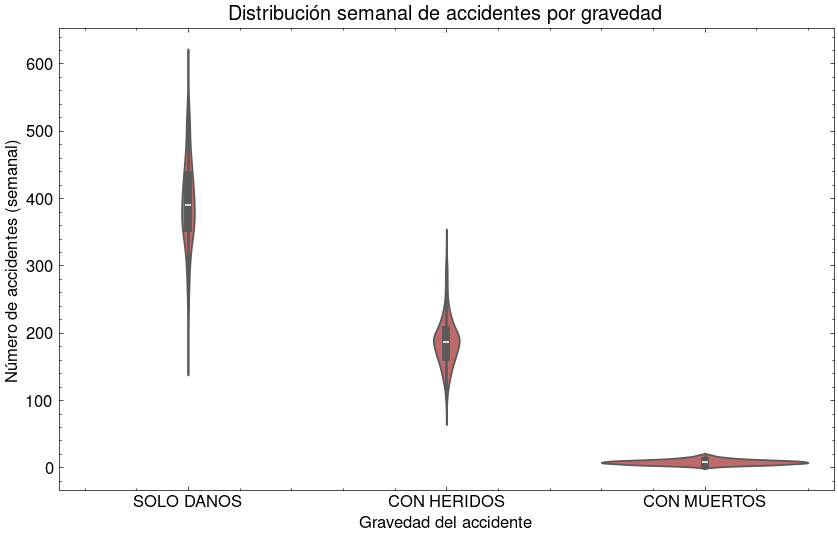

In [92]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.violinplot(
    x="GRAVEDAD",
    y="value",
    color="indianred",
    data=gravity_df,
    ax=ax,
)

ax.set(
    title="Distribución semanal de accidentes por gravedad",
    xlabel="Gravedad del accidente",
    ylabel="Número de accidentes (semanal)",
)

plt.xticks(rotation=0, ha="center")
fig.savefig(VIOLINPLOT_FIGURES_DIR / "gravedad_weekly.pdf")
plt.show()

### CLASE

In [93]:
class_df = transform_resample_data_for_boxplot(
    resample_df, "CLASE", multi_index=True
)

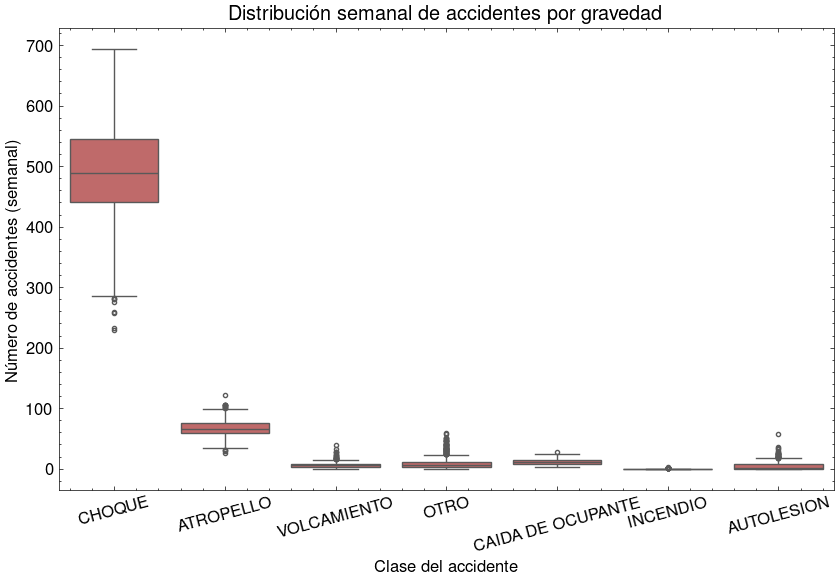

In [94]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(
    x="CLASE",
    y="value",
    color="indianred",
    data=class_df,
    ax=ax,
)

ax.set(
    title="Distribución semanal de accidentes por gravedad",
    xlabel="Clase del accidente",
    ylabel="Número de accidentes (semanal)",
)

plt.xticks(rotation=15, ha="center")
fig.savefig(BOXPLOT_FIGURES_DIR / "clase_weekly.pdf")
plt.show()

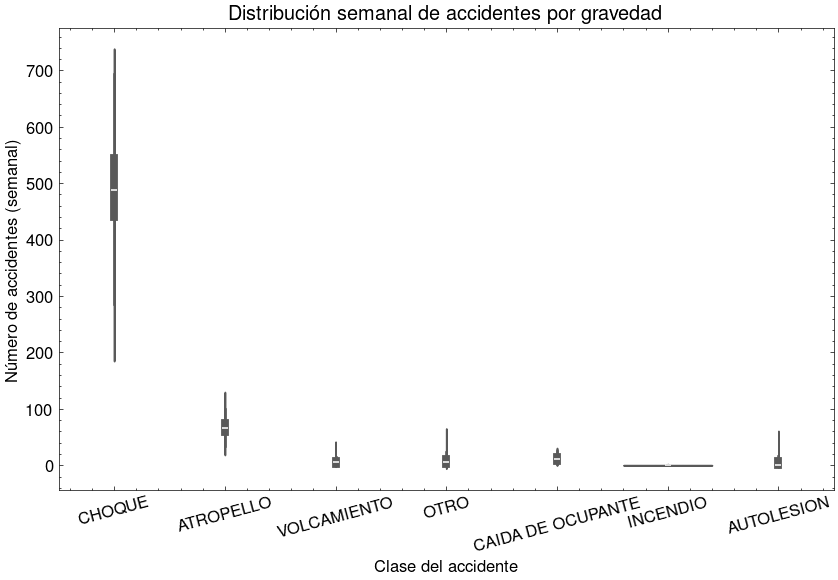

In [95]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.violinplot(
    x="CLASE",
    y="value",
    color="indianred",
    data=class_df,
    ax=ax,
)

ax.set(
    title="Distribución semanal de accidentes por gravedad",
    xlabel="Clase del accidente",
    ylabel="Número de accidentes (semanal)",
)

plt.xticks(rotation=15, ha="center")
fig.savefig(VIOLINPLOT_FIGURES_DIR / "clase_weekly.pdf")
plt.show()